In [1]:
# 1. Adult Census Income データセットのダウンロード
!kaggle datasets download -d uciml/adult-census-income
!unzip -o adult-census-income.zip

import pandas as pd
import numpy as np

# 2. データの読み込み
# 欠損値が '?' として記録されているため、na_values='?' と指定してNaNとして読み込む
# また、文字列の先頭にスペースが入っていることがあるため、skipinitialspace=True を指定
df = pd.read_csv('adult.csv', na_values='?', skipinitialspace=True)

# 3. データの確認
print(f"データの形状: {df.shape}")
print("\n--- 欠損値の確認 ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

display(df.head())

Dataset URL: https://www.kaggle.com/datasets/uciml/adult-census-income
License(s): CC0-1.0
100% 450k/450k [00:00<00:00, 35.8MB/s]

Archive:  adult-census-income.zip
  inflating: adult.csv               
データの形状: (32561, 15)

--- 欠損値の確認 ---
workclass         1836
occupation        1843
native.country     583
dtype: int64


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


/tmp/ipykernel_2646/2475723765.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_viz, x='income_binary', y='workclass', errorbar=None, palette='viridis', ax=axes[0])
/tmp/ipykernel_2646/2475723765.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_viz, x='income_binary', y='occupation', errorbar=None, palette='viridis', ax=axes[1])


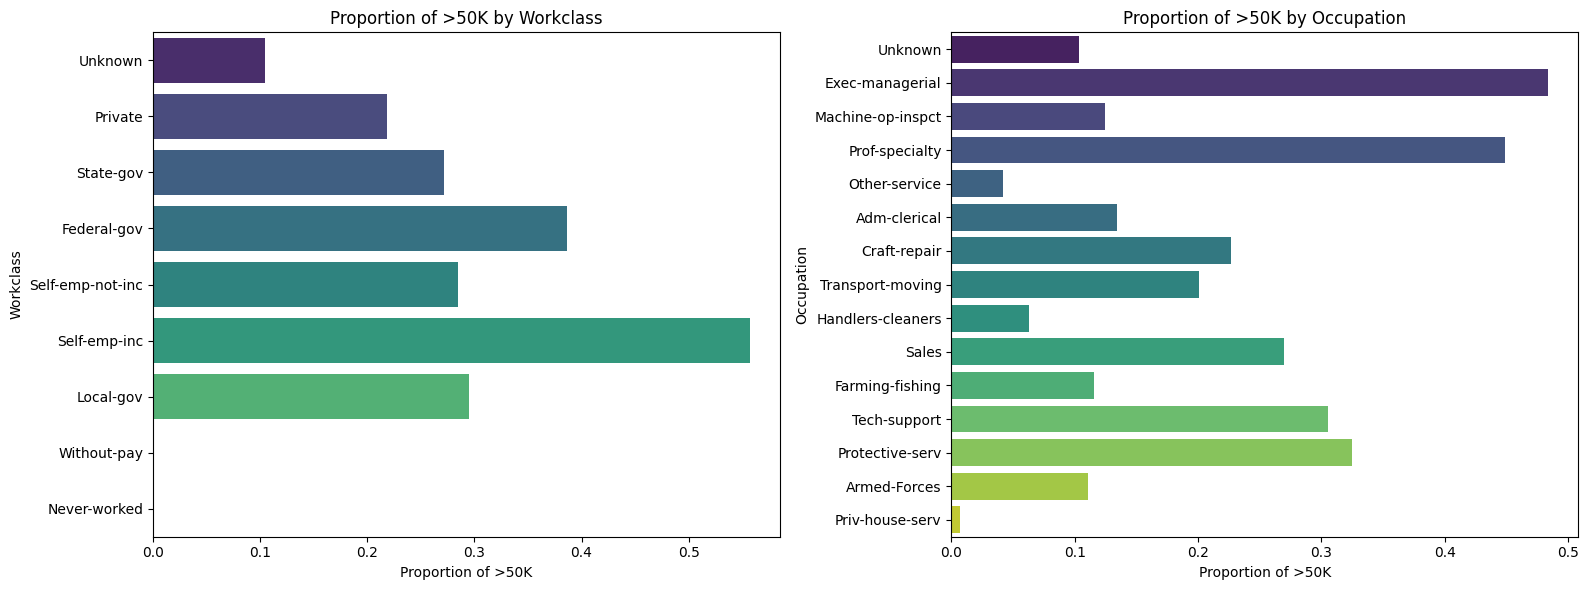

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 検証用に一時的なデータフレームを作成
df_viz = df.copy()

# 1. 欠損値の補完
# workclass と occupation は 'Unknown' で埋める
df_viz['workclass'] = df_viz['workclass'].fillna('Unknown')
df_viz['occupation'] = df_viz['occupation'].fillna('Unknown')

# native.country は最頻値（United-States）で埋める
mode_country = df_viz['native.country'].mode()[0]
df_viz['native.country'] = df_viz['native.country'].fillna(mode_country)

# 2. 目的変数 (income) を数値に変換
# '<=50K' を 0, '>50K' を 1 に変換
df_viz['income_binary'] = df_viz['income'].apply(lambda x: 1 if x == '>50K' else 0)

# 3. グラフの作成: 各カテゴリにおける高収入(>50K)の割合
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# workclassの可視化
sns.barplot(data=df_viz, x='income_binary', y='workclass', errorbar=None, palette='viridis', ax=axes[0])
axes[0].set_title('Proportion of >50K by Workclass')
axes[0].set_xlabel('Proportion of >50K')
axes[0].set_ylabel('Workclass')

# occupationの可視化
sns.barplot(data=df_viz, x='income_binary', y='occupation', errorbar=None, palette='viridis', ax=axes[1])
axes[1].set_title('Proportion of >50K by Occupation')
axes[1].set_xlabel('Proportion of >50K')
axes[1].set_ylabel('Occupation')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2646/2843048887.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Is_Married', y='income_binary', errorbar=None, palette='Set2', ax=axes[0])
/tmp/ipykernel_2646/2843048887.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Married (0)', 'Married (1)'])
/tmp/ipykernel_2646/2843048887.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Has_Capital_Activity', y='income_binary', errorbar=None, palette='Set2', ax=axes[1])
/tmp/ipykernel_2646/2843048887.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

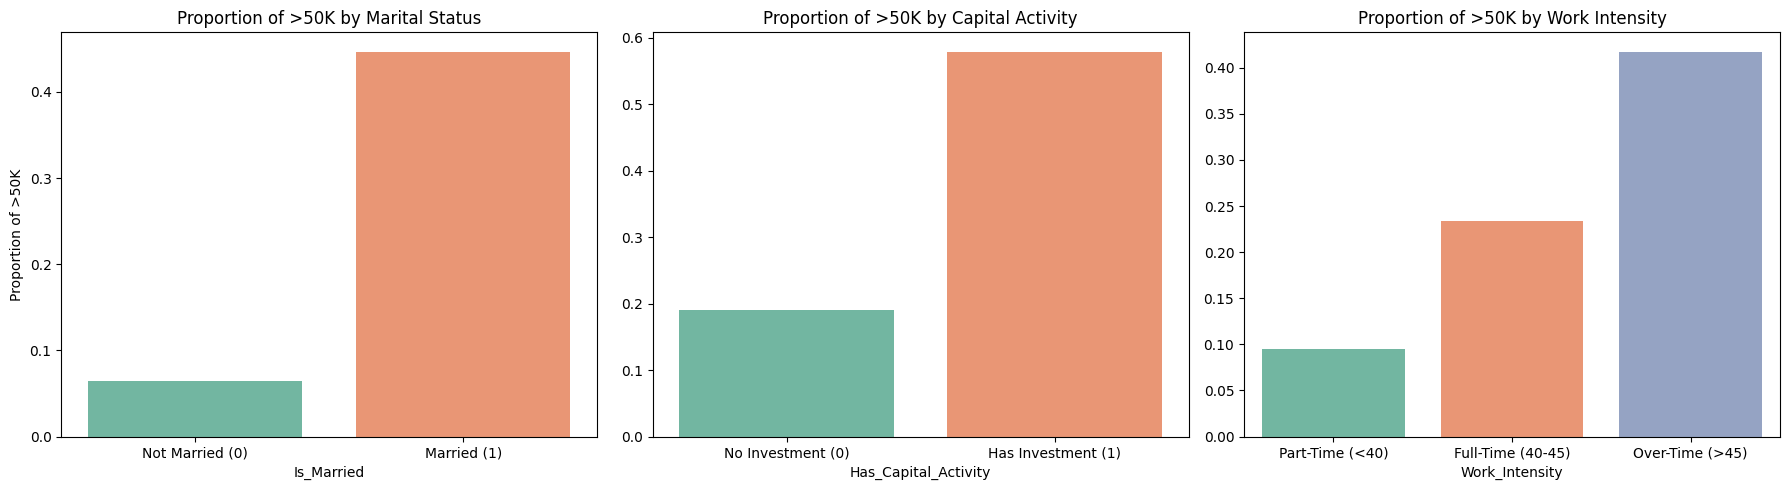

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 前回の欠損値補完とターゲットの数値化を適用
df['workclass'] = df['workclass'].fillna('Unknown')
df['occupation'] = df['occupation'].fillna('Unknown')
df['native.country'] = df['native.country'].fillna(df['native.country'].mode()[0])
df['income_binary'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# 1. 特徴量エンジニアリングの実行

# ① Is_Married (既婚フラグ)
# 'Married-civ-spouse' または 'Married-AF-spouse' を既婚(1)とする
married_cats = ['Married-civ-spouse', 'Married-AF-spouse']
df['Is_Married'] = df['marital.status'].apply(lambda x: 1 if x in married_cats else 0)

# ② Capital_Net と Has_Capital_Activity (純資本損益と投資活動フラグ)
df['Capital_Net'] = df['capital.gain'] - df['capital.loss']
# 投資行動がある(損益が0ではない)場合は1、ない場合は0
df['Has_Capital_Activity'] = df['Capital_Net'].apply(lambda x: 1 if x != 0 else 0)

# ③ Work_Intensity (労働強度のカテゴリ化)
def categorize_hours(h):
    if h < 40:
        return 'Part-Time (<40)'
    elif 40 <= h <= 45:
        return 'Full-Time (40-45)'
    else:
        return 'Over-Time (>45)'

df['Work_Intensity'] = df['hours.per.week'].apply(categorize_hours)

# 2. 有効性の検証（可視化）
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ① Is_Married の検証
sns.barplot(data=df, x='Is_Married', y='income_binary', errorbar=None, palette='Set2', ax=axes[0])
axes[0].set_title('Proportion of >50K by Marital Status')
axes[0].set_xticklabels(['Not Married (0)', 'Married (1)'])
axes[0].set_ylabel('Proportion of >50K')

# ② Has_Capital_Activity の検証
sns.barplot(data=df, x='Has_Capital_Activity', y='income_binary', errorbar=None, palette='Set2', ax=axes[1])
axes[1].set_title('Proportion of >50K by Capital Activity')
axes[1].set_xticklabels(['No Investment (0)', 'Has Investment (1)'])
axes[1].set_ylabel('')

# ③ Work_Intensity の検証
# 順序を指定して表示
order = ['Part-Time (<40)', 'Full-Time (40-45)', 'Over-Time (>45)']
sns.barplot(data=df, x='Work_Intensity', y='income_binary', order=order, errorbar=None, palette='Set2', ax=axes[2])
axes[2].set_title('Proportion of >50K by Work Intensity')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

if 'income_binary' in df.columns:
    df = df.drop('income_binary', axis=1)

# 1. 欠損値補完の確定
df['workclass'] = df['workclass'].fillna('Unknown')
df['occupation'] = df['occupation'].fillna('Unknown')
df['native.country'] = df['native.country'].fillna(df['native.country'].mode()[0])

# 2. 特徴量エンジニアリングの確定
# 既婚フラグ
married_cats = ['Married-civ-spouse', 'Married-AF-spouse']
df['Is_Married'] = df['marital.status'].apply(lambda x: 1 if x in married_cats else 0)

# 純資本損益と投資フラグ
df['Capital_Net'] = df['capital.gain'] - df['capital.loss']
df['Has_Capital_Activity'] = df['Capital_Net'].apply(lambda x: 1 if x != 0 else 0)

# 労働強度
def categorize_hours(h):
    if h < 40: return 'Part-Time'
    elif 40 <= h <= 45: return 'Full-Time'
    else: return 'Over-Time'
df['Work_Intensity'] = df['hours.per.week'].apply(categorize_hours)

# 3. 目的変数の数値化
if df['income'].dtype == 'object':
    df['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# 4. 不要な列の削除
df_cleaned = df.drop(['fnlwgt'], axis=1)

# 5. カテゴリ変数の数値化 (One-Hot Encoding)
df_encoded = pd.get_dummies(df_cleaned, drop_first=True)

# 6. 特徴量(X)と目的変数(y)の分離
X = df_encoded.drop('income', axis=1)
y = df_encoded['income']

# 7. 学習データとテストデータの分割 (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- 前処理が完了しました ---")
print(f"エンコーディング後の特徴量数: {X_train.shape[1]}")
print(f"学習データ件数: {X_train.shape[0]}件")

--- 前処理が完了しました ---
エンコーディング後の特徴量数: 103
学習データ件数: 26048件


--- ランダムフォレストの評価結果 ---
Accuracy (正解率):  0.8485
Precision (適合率): 0.7170
Recall (再現率/感度): 0.6122
F1-score:           0.6605



/tmp/ipykernel_2646/4021652491.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importances.head(15), x='Importance', y='Feature', palette='viridis')


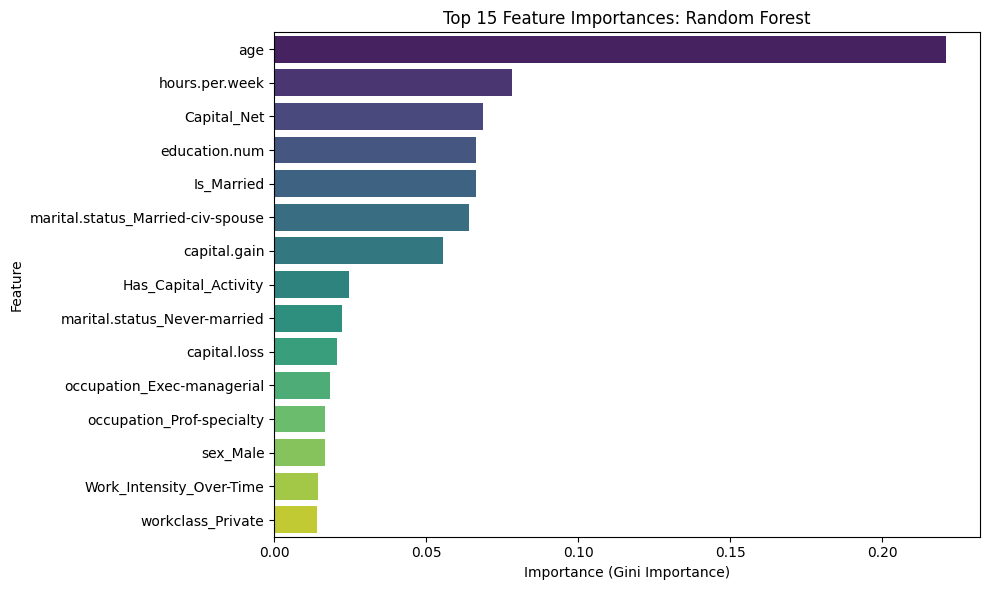

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. ランダムフォレストモデルの定義と学習
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. テストデータに対する予測と評価
y_pred_rf = rf_model.predict(X_test)

print("--- ランダムフォレストの評価結果 ---")
print(f"Accuracy (正解率):  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision (適合率): {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall (再現率/感度): {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score:           {f1_score(y_test, y_pred_rf):.4f}\n")

# 3. 特徴量重要度 (Feature Importance) の抽出
rf_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. 特徴量重要度の上位15個を可視化
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importances.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances: Random Forest')
plt.xlabel('Importance (Gini Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

[LightGBM] [Info] Number of positive: 6273, number of negative: 19775
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014711 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 661
[LightGBM] [Info] Number of data points in the train set: 26048, number of used features: 89
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240825 -> initscore=-1.148164
[LightGBM] [Info] Start training from score -1.148164
--- LightGBMの評価結果 ---
Accuracy (正解率):  0.8710
Precision (適合率): 0.7813
Recall (再現率/感度): 0.6448
F1-score:           0.7065



/tmp/ipykernel_2646/102327095.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lgb_importances.head(15), x='Importance', y='Feature', palette='magma')


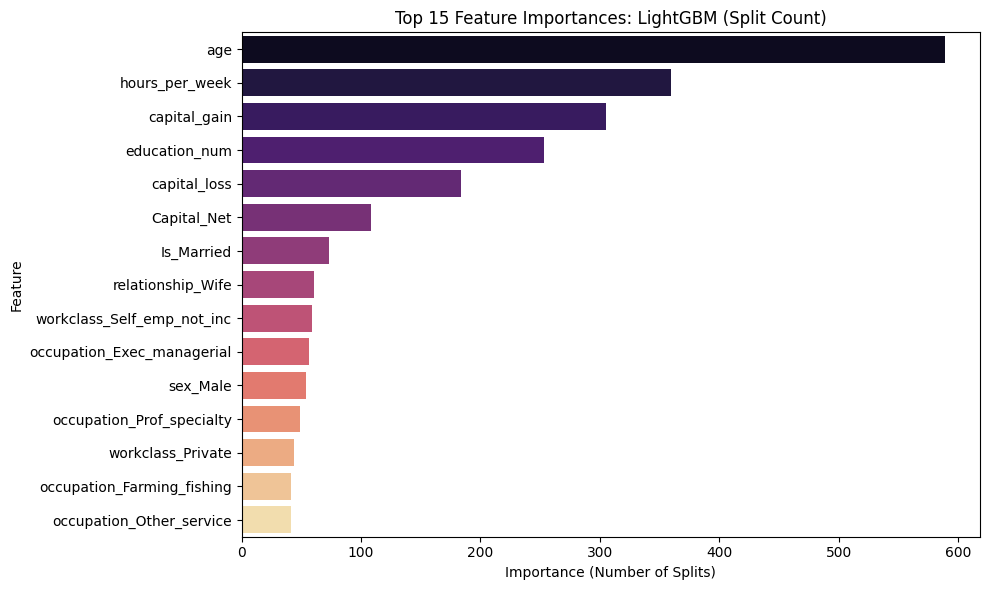

In [12]:
import re
from lightgbm import LGBMClassifier

# 1. LightGBMのエラー回避のため、列名の特殊文字をアンダースコアに置換
X_train_lgb = X_train.rename(columns=lambda x: re.sub(r'[^A-Za-z0-9_]+', '_', x))
X_test_lgb  = X_test.rename(columns=lambda x: re.sub(r'[^A-Za-z0-9_]+', '_', x))

# 2. LightGBMモデルの定義と学習
lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train_lgb, y_train)

# 3. テストデータに対する予測と評価
y_pred_lgb = lgb_model.predict(X_test_lgb)

print("--- LightGBMの評価結果 ---")
print(f"Accuracy (正解率):  {accuracy_score(y_test, y_pred_lgb):.4f}")
print(f"Precision (適合率): {precision_score(y_test, y_pred_lgb):.4f}")
print(f"Recall (再現率/感度): {recall_score(y_test, y_pred_lgb):.4f}")
print(f"F1-score:           {f1_score(y_test, y_pred_lgb):.4f}\n")

# 4. 特徴量重要度の比較用可視化 (LightGBM)
lgb_importances = pd.DataFrame({
    'Feature': X_train_lgb.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=lgb_importances.head(15), x='Importance', y='Feature', palette='magma')
plt.title('Top 15 Feature Importances: LightGBM (Split Count)')
plt.xlabel('Importance (Number of Splits)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. 探索するハイパーパラメータの組み合わせを定義
param_grid = {
    'learning_rate': [0.05, 0.1],  # 学習率
    'max_depth': [3, 5, 7],        # 木の深さ
    'num_leaves': [31, 50],        # 葉の最大数
    'n_estimators': [100, 200]     # 作成する木の数
}

# 2. GridSearchCVの設定
lgb_base = LGBMClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=lgb_base,
    param_grid=param_grid,
    cv=3,          # 3分割交差検証で評価
    scoring='f1',  # F1-scoreを最大化する組み合わせを探す
    n_jobs=-1,     # CPUの全コアを使って並列処理
    verbose=1      # 進行状況を表示
)

grid_search.fit(X_train_lgb, y_train)

# 3. 最適なパラメータの確認
print("\nチューニング完了")
print(f"見つかった最適なパラメータ: {grid_search.best_params_}")

# 4. 最適なモデルでテストデータを最終評価
best_lgb_model = grid_search.best_estimator_
y_pred_best = best_lgb_model.predict(X_test_lgb)

print("\n--- チューニング後 LightGBM の最終評価結果 ---")
print(f"Accuracy (正解率):  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision (適合率): {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall (再現率/感度): {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-score:           {f1_score(y_test, y_pred_best):.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[LightGBM] [Info] Number of positive: 6273, number of negative: 19775
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005270 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 661
[LightGBM] [Info] Number of data points in the train set: 26048, number of used features: 89
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240825 -> initscore=-1.148164
[LightGBM] [Info] Start training from score -1.148164
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB